# The benchmark problems, against their references

Every problem in the paper, run and compared against a value obtained some
other way. Where a closed form exists it is used; otherwise the reference is
crude Monte Carlo at a sample count the estimator is meant to make
unnecessary.

Checking against an independent answer is the whole point. Each of these
problems has, at some stage, been quietly wrong in a way that no unit test
noticed — the four-mode limit state had `sqrt(3.5)` where the paper has
`7/sqrt(2)`, the oscillator never integrated its equations of motion, and the
heat transfer field solver diverged. All three produced plausible-looking
output.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

from safe_ice import SafeICE
from safe_ice.problems.benchmarks import BenchmarkProblems
from safe_ice.problems.heat_transfer import HeatTransferProblem

plt.rcParams.update({"figure.dpi": 110, "font.size": 10, "figure.facecolor": "white"})

## The problems and where their references come from

In [2]:
PROBLEMS = [
    {
        "name": "four-mode",
        "section": "4.1",
        "g": BenchmarkProblems.four_mode_series_system(z=1.0),
        "d": 2,
        "reference": 6.465e-05,
        "source": "crude MC, 2e7 samples (+/- 2.8%)",
    },
    {
        "name": "three-mode",
        "section": "4.2",
        "g": BenchmarkProblems.three_mode_problem(z=3.0),
        "d": 2,
        "reference": 3.475e-03,
        "source": "crude MC, 2e7 samples (+/- 0.4%)",
    },
    {
        "name": "oscillator",
        "section": "4.3",
        "g": BenchmarkProblems.nonlinear_oscillator(z=0.05),
        "d": 10,
        "reference": 1.798e-03,
        "source": "crude MC, 2e6 samples (+/- 1.7%)",
    },
    {
        "name": "two-mode",
        "section": "4.4",
        "g": BenchmarkProblems.two_mode_opposite_directions(z=3.0),
        "d": 2,
        "reference": float(2 * stats.norm.cdf(-3.0)),
        "source": "closed form, 2*Phi(-z)",
    },
    {
        "name": "heat transfer",
        "section": "4.5",
        "g": HeatTransferProblem().create_limit_state_function(),
        "d": 10,
        "reference": 4.69e-07,
        "source": "paper, subset simulation",
    },
]

for p in PROBLEMS:
    print(
        f"  {p['name']:15s} section {p['section']}  d={p['d']:3d}  "
        f"P_F = {p['reference']:.3e}   {p['source']}"
    )

  four-mode       section 4.1  d=  2  P_F = 6.465e-05   crude MC, 2e7 samples (+/- 2.8%)
  three-mode      section 4.2  d=  2  P_F = 3.475e-03   crude MC, 2e7 samples (+/- 0.4%)
  oscillator      section 4.3  d= 10  P_F = 1.798e-03   crude MC, 2e6 samples (+/- 1.7%)
  two-mode        section 4.4  d=  2  P_F = 2.700e-03   closed form, 2*Phi(-z)
  heat transfer   section 4.5  d= 10  P_F = 4.690e-07   paper, subset simulation


The two-mode system is the useful one to check first: its failure probability
is $2\Phi(-z)$ exactly, for any dimension. A closed form leaves nowhere for a
plausible-looking error to hide.

## Running them

Three seeds each. A single run is a draw from a distribution, so the median
is reported alongside the spread.

In [3]:
SEEDS = range(3)

for problem in PROBLEMS:
    estimates = []
    for seed in SEEDS:
        ice = SafeICE(
            limit_state_function=problem["g"],
            dimension=problem["d"],
            N=1000,
            max_iterations=15,
            random_state=seed,
        )
        pf, _ = ice.run(verbose=False)
        estimates.append(pf)
    problem["estimates"] = np.array(estimates)
    problem["median"] = float(np.median(estimates))

print(
    f"{'problem':16s} {'reference':>11s} {'median':>11s}  {'ratio':>6s}  {'worst seed':>10s}"
)
print("-" * 60)
for p in PROBLEMS:
    ratios = p["estimates"] / p["reference"]
    worst = ratios[np.argmax(np.abs(np.log(ratios)))]
    print(
        f"{p['name']:16s} {p['reference']:11.3e} {p['median']:11.3e}  "
        f"{p['median'] / p['reference']:5.2f}x  {worst:9.2f}x"
    )

problem            reference      median   ratio  worst seed
------------------------------------------------------------
four-mode          6.465e-05   6.439e-05   1.00x       0.83x
three-mode         3.475e-03   3.643e-03   1.05x       1.10x
oscillator         1.798e-03   1.578e-03   0.88x       0.88x
two-mode           2.700e-03   2.879e-03   1.07x       1.07x
heat transfer      4.690e-07   3.168e-07   0.68x       0.63x


The last column is the individual run furthest from the reference, not the
median. It is the more demanding number: a median can look healthy while
hiding a run that collapsed, which is exactly what used to happen on the heat
transfer problem before the search for the smoothing parameter was fixed.

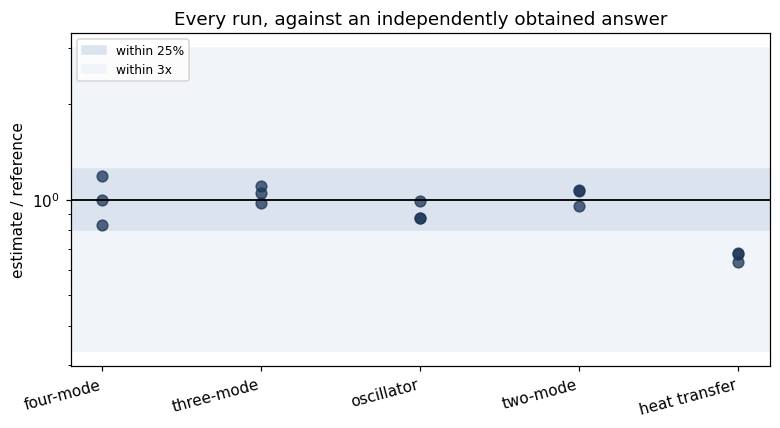

In [4]:
fig, ax = plt.subplots(figsize=(7.2, 4.0))
positions = np.arange(len(PROBLEMS))

for i, p in enumerate(PROBLEMS):
    ratios = p["estimates"] / p["reference"]
    ax.plot([i] * len(ratios), ratios, "o", color="#1d3557", ms=7, alpha=0.75)

ax.axhline(1.0, color="black", lw=1.2)
ax.axhspan(0.8, 1.25, color="#dbe4ee", zorder=0, label="within 25%")
ax.axhspan(1 / 3, 3.0, color="#f1f4f8", zorder=-1, label="within 3x")
ax.set_yscale("log")
ax.set_xticks(positions)
ax.set_xticklabels([p["name"] for p in PROBLEMS], rotation=15, ha="right")
ax.set_ylabel("estimate / reference")
ax.set_title("Every run, against an independently obtained answer")
ax.legend(fontsize=8, loc="upper left")
plt.tight_layout()
plt.show()

## The cost

What makes this worth doing is the number of limit-state evaluations. Crude
Monte Carlo needs on the order of $1/P_F$ samples to see a single failure.

In [5]:
print(
    f"{'problem':16s} {'P_F':>10s} {'MC for ~100 failures':>22s} {'Safe-ICE evals':>16s}"
)
print("-" * 68)
for p in PROBLEMS:
    ice = SafeICE(
        limit_state_function=p["g"],
        dimension=p["d"],
        N=1000,
        max_iterations=15,
        random_state=0,
    )
    _pf, results = ice.run(verbose=False)
    evaluations = ice.N * (len(results["iterations"]) + 1)
    mc_needed = 100 / p["reference"]
    print(
        f"{p['name']:16s} {p['reference']:10.2e} {mc_needed:22,.0f} {evaluations:16,d}"
    )

problem                 P_F   MC for ~100 failures   Safe-ICE evals
--------------------------------------------------------------------


four-mode          6.46e-05              1,546,790            3,000


three-mode         3.47e-03                 28,777            3,000


oscillator         1.80e-03                 55,617            4,000
two-mode           2.70e-03                 37,040            3,000


heat transfer      4.69e-07            213,219,616            5,000


For the heat transfer problem, crude Monte Carlo would need about two hundred
million finite-element solves to see a hundred failures. The estimator uses
five thousand.

## A note on the oscillator

The nonlinear oscillator is the one problem here that is not an algebraic
expression: each evaluation integrates a Bouc-Wen hysteretic system with
fourth-order Runge-Kutta to $t = 8\,\mathrm{s}$. Its threshold controls how
rare failure is, and the paper sweeps it from 0.05 to 0.08.

In [6]:
for z, expected in ((0.05, 1.798e-03), (0.06, 1.475e-04), (0.07, 4.5e-06)):
    ice = SafeICE(
        limit_state_function=BenchmarkProblems.nonlinear_oscillator(z=z),
        dimension=10,
        N=1000,
        max_iterations=15,
        random_state=0,
    )
    pf, _ = ice.run(verbose=False)
    print(
        f"  z={z:.2f}:  Safe-ICE {pf:.3e}   crude MC {expected:.3e}   ratio {pf / expected:.2f}x"
    )

  z=0.05:  Safe-ICE 1.578e-03   crude MC 1.798e-03   ratio 0.88x


  z=0.06:  Safe-ICE 1.135e-04   crude MC 1.475e-04   ratio 0.77x


  z=0.07:  Safe-ICE 4.187e-06   crude MC 4.500e-06   ratio 0.93x


Three orders of magnitude of failure probability, tracked with the same
thousand samples per iteration throughout.